# 4 · Deep learning & Prophet forecasting

The two heaviest optional extras in one notebook: PyTorch regressors
(`MLPRegressor` / `LSTMRegressor` / `CNNRegressor`, the `deep` extra) and
Prophet-based forecasting (`ProphetForecaster` and `HybridProphetRegressor`,
the `forecast` extra). Both are optional — the library imports fine without
them — so this notebook checks availability first and reports what to install
if a section can't run.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "reproductions"))

import importlib.util
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from _synthetic import make_graz_hourly

from nextaire_tools import Pipeline
from nextaire_tools.preprocessing import MissingValueHandler, OutlierHandler, TemporalFeatures, Scaler
from nextaire_tools.models import temporal_train_test_split, regression_metrics

HAS_TORCH = importlib.util.find_spec("torch") is not None
HAS_PROPHET = importlib.util.find_spec("prophet") is not None
print(f"torch available:   {HAS_TORCH}  (pip install 'nextaire_tools[deep]')")
print(f"prophet available: {HAS_PROPHET}  (pip install 'nextaire_tools[forecast]')")

torch available:   True  (pip install 'nextaire_tools[deep]')
prophet available: True  (pip install 'nextaire_tools[forecast]')


## Example data

Same synthetic Graz-style station used elsewhere, cleaned and feature-engineered
with the usual `Pipeline`, then split chronologically — the deep models get
plain NumPy arrays, the Prophet models work on the raw hourly series.

In [2]:
raw = make_graz_hourly(n_days=200, seed=2)

pipe = Pipeline([
    MissingValueHandler(strategy="interpolate", limit=3),
    OutlierHandler(columns=["no2", "o3", "pm10"], method="iqr", strategy="clip"),
    TemporalFeatures(cyclical=("hour", "dayofweek", "dayofyear")),
    MissingValueHandler(strategy="bfill"),  # mop up any gap longer than the interpolate limit
    Scaler(method="standard"),
])
clean = pipe.fit_transform(raw)

target = "no2"
train, test = temporal_train_test_split(clean, test_size=0.25)
X_train, y_train = train.drop(columns=[target]).to_numpy(), train[target].to_numpy()
X_test, y_test = test.drop(columns=[target]).to_numpy(), test[target].to_numpy()
print("train:", X_train.shape, " test:", X_test.shape)

train: (3600, 24)  test: (1200, 24)


## Deep learning regressors (`[deep]`)

`MLPRegressor`, `LSTMRegressor`, and `CNNRegressor` share a scikit-learn
`fit` / `predict` API and standardise inputs and targets internally, so no
separate scaling step is needed for them specifically. The windowed models
(LSTM/CNN) consume sliding look-back windows and return `NaN` for the first
`window` rows of each split — there's no full history yet — so metrics are
computed on the non-NaN rows only.

In [3]:
if HAS_TORCH:
    from nextaire_tools.models import MLPRegressor, LSTMRegressor, CNNRegressor

    deep_models = {
        "mlp": MLPRegressor(hidden_sizes=(32, 16), epochs=60, random_state=0),
        "lstm": LSTMRegressor(window=24, hidden_size=32, epochs=30, random_state=0),
        "cnn": CNNRegressor(window=24, channels=(16, 16), epochs=30, random_state=0),
    }

    deep_predictions = {}
    deep_rows = {}
    for name, model in deep_models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        deep_predictions[name] = pred
        mask = ~np.isnan(pred)
        deep_rows[name] = regression_metrics(y_test[mask], pred[mask], metrics=["mae", "rmse", "r2"])

    deep_report = pd.DataFrame(deep_rows).T.round(3)
else:
    deep_report = None
    print("torch not installed — skipping the deep-learning section")
deep_report

,mae,rmse,r2
mlp,0.337,0.416,0.833
lstm,0.508,0.661,0.580
cnn,0.528,0.666,0.573


### Predictions vs observed (LSTM)

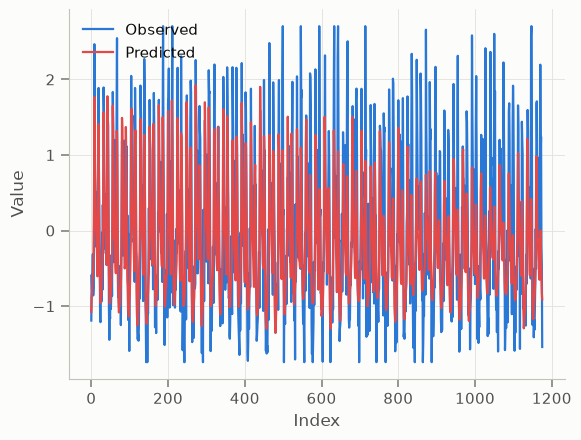

In [4]:
if HAS_TORCH:
    from nextaire_tools.viz import plot_predictions

    mask = ~np.isnan(deep_predictions["lstm"])
    plot_predictions(y_test[mask], deep_predictions["lstm"][mask], kind="timeseries")
    plt.show()

## Prophet forecasting (`[forecast]`)

`ProphetForecaster` wraps Facebook Prophet behind a small, consistent
interface. It suits the strong daily/weekly cycles of urban NO₂: fit it on
the training history and forecast the held-out 14 days directly from
timestamps, with calibrated uncertainty intervals.

C:\Users\valpe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


21:47:46 - cmdstanpy - INFO - Chain [1] start processing


21:47:49 - cmdstanpy - INFO - Chain [1] done processing


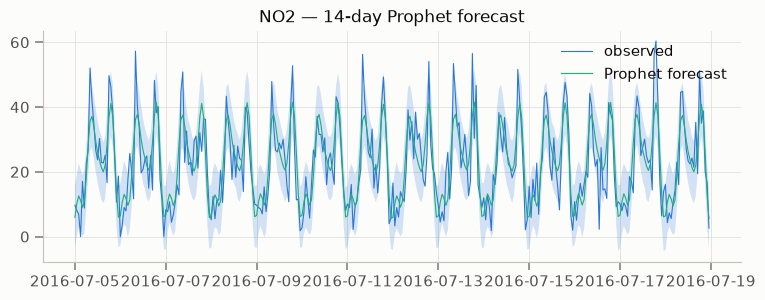

{'mae': 5.8371734181101855,
 'rmse': 7.280119261392142,
 'r2': 0.6919156584829314}

In [5]:
if HAS_PROPHET:
    from nextaire_tools.models import ProphetForecaster

    series = raw["no2"].asfreq("h").interpolate()
    n_test = 24 * 14
    train_series, test_series = series.iloc[:-n_test], series.iloc[-n_test:]

    forecaster = ProphetForecaster(daily_seasonality=True, weekly_seasonality=True).fit(train_series)
    forecast = forecaster.predict(periods=n_test, freq="h").set_index("ds").reindex(test_series.index)

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(test_series.index, test_series.to_numpy(), lw=0.8, label="observed")
    ax.plot(forecast.index, forecast["yhat"], lw=0.8, label="Prophet forecast")
    ax.fill_between(forecast.index, forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2)
    ax.set_title("NO2 — 14-day Prophet forecast"); ax.legend()
    plt.show()

    prophet_metrics = regression_metrics(
        test_series.to_numpy(), forecast["yhat"].to_numpy(), metrics=["mae", "rmse", "r2"]
    )
else:
    prophet_metrics = None
    print("prophet not installed — skipping the forecasting section")
prophet_metrics

## Hybrid Prophet + Random Forest

`HybridProphetRegressor` fits Prophet on the target series and appends its
in-sample forecast (plus trend / seasonal components) as extra features for a
downstream regressor — a Random Forest by default. Prophet captures the
trend and daily/weekly seasonality; the regressor captures what's left,
including the meteorological and calendar features already in `clean`.

In [6]:
if HAS_PROPHET:
    from nextaire_tools.models import HybridProphetRegressor

    hybrid = HybridProphetRegressor().fit(train.drop(columns=[target]), train[target])
    hybrid_pred = hybrid.predict(test.drop(columns=[target]))
    hybrid_metrics = regression_metrics(
        test[target].to_numpy(), hybrid_pred, metrics=["mae", "rmse", "r2", "index_of_agreement"]
    )
    print(f"Prophet features used: {hybrid.prophet_feature_names_}")
else:
    hybrid_metrics = None
hybrid_metrics

21:47:50 - cmdstanpy - INFO - Chain [1] start processing


21:47:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet features used: ['yhat', 'yhat_lower', 'yhat_upper', 'trend', 'weekly', 'daily']


{'mae': 0.32740869204799816,
 'rmse': 0.4098001227725334,
 'r2': 0.837901105516902,
 'index_of_agreement': 0.9533713744541279}

Back to **[1 · Quickstart](01_quickstart.ipynb)**, **[2 · Preprocessing & feature tour](02_preprocessing_and_features.ipynb)**,
or **[3 · Reproducing the papers](03_reproduce_papers.ipynb)**.